# Phase 3: Predictive Modeling & Diagnostic Analysis

| | |
|---|---|
| **Notebook** | Phase3_Model_Analysis_Diagnostics.ipynb |
| **Author** | Ashok Bhairwal |
| **Course** | AAI 500 - Applied Statistics & AI |
| **Dataset** | Credit Risk Modeling Dataset |
| **Phase** | Phase 3 |
| **Date** | June 07, 2026 |
| **GitHub** | https://github.com/diaeshantony-usd/applied-statistics-and-ai-team-project |


## Objectives


This notebook completes **Phase 3** of the team project, focusing on:

1. **Multiple Linear Regression (OLS)** to predict `loan_int_rate` from borrower/loan features
2. **Regression Diagnostics:**
   - Variance Inflation Factor (VIF) for multicollinearity detection
   - Q-Q plot for residual normality assessment
   - Breusch-Pagan test for homoscedasticity validation
   - Additional residual plots for comprehensive validation
3. **Logistic Regression (GLM)** to predict `loan_status` (default probability)
4. **Model Interpretation** via odds ratios and coefficient analysis
5. **Model Comparison** and business implications


## Dataset


**Source:** `data/processed/phase2/credit_risk_cleaned.csv` (from Phase 2)  
**Rows:** 29,567 observations  
**Features:** 12 original columns → 19 after encoding  
**Targets:**
- OLS: `loan_int_rate` (continuous, 5.42% - 23.22%)
- GLM: `loan_status` (binary, 0=paid, 1=default)

---

## 1. Setup and Configuration

In [86]:
import pandas as pd
import numpy as np
import warnings
from pathlib import Path
from datetime import datetime

# Statistical modeling
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats
from scipy.stats import shapiro

# Train/Test split & evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model persistence
import joblib
import json

from tabulate import tabulate


# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)  # For reproducibility

print("[INFO] All libraries imported successfully")
print("[INFO] Random seed set to 42 for reproducibility")

[INFO] All libraries imported successfully
[INFO] Random seed set to 42 for reproducibility


In [87]:
# =====================================================
# CONFIGURATION PARAMETERS
# =====================================================

# File paths
DATA_FILE = "data/processed/phase2/credit_risk_cleaned.csv"
OUTPUT_PREPROCESSED = "data/processed/phase3/credit_risk_cleaned_preprocessed.csv"
MODEL_DIR = Path("data/models/diagnostics/")

# Train/Test split parameters
TEST_SIZE = 0.20  # 20% test, 80% train
RANDOM_STATE = 42  # For reproducibility

# Modeling parameters
FEATURES_REGRESSION = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "loan_grade_enc",
    "home_ownership_enc",
    "cb_person_default_enc",
]

TARGET_CONTINUOUS = "loan_int_rate"  # For OLS
TARGET_BINARY = "loan_status"        # For GLM

# Imputation strategies
MEDIAN_COLS = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_percent_income",
    "cb_person_cred_hist_length",
]

MODE_COLS = [
    "loan_grade_enc",
    "home_ownership_enc",
    "cb_person_default_enc",
]

# Encoding mappings
GRADE_MAPPING = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
HOME_MAPPING = {'OWN': 0, 'RENT': 1, 'MORTGAGE': 2, 'OTHER': 3}
DEFAULT_MAPPING = {'N': 0, 'Y': 1}

# Diagnostic thresholds
VIF_THRESHOLD = 10
ALPHA = 0.05

print("[INFO] Configuration loaded successfully")
print(f"[INFO] Train/Test Split: {int((1-TEST_SIZE)*100)}% train / {int(TEST_SIZE*100)}% test")
print(f"[INFO] Target for OLS: {TARGET_CONTINUOUS}")
print(f"[INFO] Target for GLM: {TARGET_BINARY}")
print(f"[INFO] Number of features: {len(FEATURES_REGRESSION)}")

[INFO] Configuration loaded successfully
[INFO] Train/Test Split: 80% train / 20% test
[INFO] Target for OLS: loan_int_rate
[INFO] Target for GLM: loan_status
[INFO] Number of features: 9


## 2. Helper Functions

In [88]:
# =====================================================
# HELPER FUNCTION: PREPROCESS REGRESSION DATA
# =====================================================

def preprocess_regression_data(df, features, target, median_cols, mode_cols):
    """
    Clean and preprocess data for regression.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    features : list
        Feature column names.
    target : str
        Target column name.
    median_cols : list
        Numeric columns to impute with median.
    mode_cols : list
        Categorical/encoded columns to impute with mode.

    Returns
    -------
    X : pd.DataFrame
        Cleaned feature dataframe.
    y : pd.Series
        Cleaned target variable.
    """

    X = df[features].copy()
    y = df[target].copy()

    # Replace infinities
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    y.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Missing value report
    null_report = pd.DataFrame({
        "Nulls": X.isnull().sum(),
        "% Miss": (X.isnull().mean() * 100).round(2)
    })
    null_report = null_report[null_report["Nulls"] > 0]

    if null_report.empty:
        print("[INFO] No missing values found in features.")
    else:
        print("[INFO] Missing values detected:")
        print(null_report.to_string())
        print()

    # Remove missing target rows
    target_nulls = y.isnull().sum()
    if target_nulls > 0:
        print(f"[INFO] Target '{target}' has {target_nulls} missing rows — dropping them.")
        mask = y.notnull()
        X = X.loc[mask].reset_index(drop=True)
        y = y.loc[mask].reset_index(drop=True)

    # Median imputation
    for col in median_cols:
        if col in X.columns and X[col].isnull().any():
            fill_val = X[col].median()
            X[col] = X[col].fillna(fill_val)
            print(f"[INFO] Imputed '{col}' with median = {fill_val:.4g}")

    # Mode imputation
    for col in mode_cols:
        if col in X.columns and X[col].isnull().any():
            fill_val = X[col].mode()[0]
            X[col] = X[col].fillna(fill_val)
            print(f"[INFO] Imputed '{col}' with mode = {fill_val}")

    # Final cleanup
    before = len(X)
    combined = pd.concat([X, y], axis=1).dropna()
    X = combined[features].reset_index(drop=True)
    y = combined[target].reset_index(drop=True)
    dropped = before - len(X)

    if dropped:
        print(f"[INFO] Dropped {dropped} row(s) that could not be imputed.")

    print(f"[INFO] Clean dataset: {len(X)} rows x {len(features)} features")

    return X, y

print("[INFO] Helper function defined successfully")

[INFO] Helper function defined successfully


## 3. Data Loading and Preprocessing

We load the Phase 1 cleaned dataset and perform encoding transformations (ordinal encoding for loan grade, home ownership, and prior-default flag; one-hot encoding for loan intent).

In [89]:
# =====================================================
# DATA LOADING
# =====================================================

try:
    df = pd.read_csv(DATA_FILE)
    print(f"[INFO] Dataset loaded successfully from: {DATA_FILE}")
    print(f"[INFO] Dataset shape before preprocessing: {df.shape}")
    print(f"\n[INFO] Column names:")
    print(df.columns.tolist())
except FileNotFoundError:
    print(f"[ERROR] File not found: {DATA_FILE}")
    print("[ERROR] Please ensure Phase 1 has been completed and the file exists.")
    raise
except Exception as e:
    print(f"[ERROR] Unexpected error loading data: {e}")
    raise

# Display first few rows
print("\n[INFO] First 5 rows of raw data:")
df.head()

[INFO] Dataset loaded successfully from: data/processed/phase2/credit_risk_cleaned.csv
[INFO] Dataset shape before preprocessing: (29567, 23)

[INFO] Column names:
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'log_person_income', 'log_loan_amnt', 'income_to_loan_ratio', 'employment_to_age_ratio', 'credit_history_to_age_ratio', 'default_on_file_binary', 'loan_grade_numeric', 'income_group', 'loan_amount_group', 'loan_percent_income_group', 'age_group']

[INFO] First 5 rows of raw data:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,...,log_loan_amnt,income_to_loan_ratio,employment_to_age_ratio,credit_history_to_age_ratio,default_on_file_binary,loan_grade_numeric,income_group,loan_amount_group,loan_percent_income_group,age_group
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,...,6.908755,9.600000,0.238095,0.095238,0,1,Low,Small,Low Burden,Young
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,...,8.612685,1.745455,0.040000,0.120000,0,2,Low,Medium,Very High Burden,Young
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,...,10.463132,1.871429,0.173913,0.086957,0,2,Middle,Very Large,Very High Burden,Young
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,...,10.463132,1.554286,0.333333,0.166667,1,2,Middle,Very Large,Very High Burden,Young
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,...,7.824446,3.960000,0.095238,0.095238,0,0,Low,Small,High Burden,Young


In [90]:
# =====================================================
# ENCODING TRANSFORMATIONS
# =====================================================

print("[INFO] Applying encoding transformations...")

# Ordinal encoding for loan grade (A=best, G=worst)
df['loan_grade_enc'] = df['loan_grade'].map(GRADE_MAPPING)
print(f"[INFO] Loan grade encoded: {df['loan_grade'].unique()} -> {sorted(df['loan_grade_enc'].unique())}")

# Ordinal encoding for home ownership
df['home_ownership_enc'] = df['person_home_ownership'].map(HOME_MAPPING)
print(f"[INFO] Home ownership encoded: {df['person_home_ownership'].unique()} -> {sorted(df['home_ownership_enc'].unique())}")

# Binary encoding for previous default
df['cb_person_default_enc'] = df['cb_person_default_on_file'].map(DEFAULT_MAPPING)
print(f"[INFO] Default flag encoded: {df['cb_person_default_on_file'].unique()} -> {sorted(df['cb_person_default_enc'].unique())}")

# One-hot encoding for loan intent (nominal categorical)
df_encoded = pd.get_dummies(
    df,
    columns=['loan_intent'],
    drop_first=True  # Avoid dummy variable trap
)

# Convert boolean dummies to integer
dummy_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[dummy_cols] = df_encoded[dummy_cols].astype(int)

print(f"[INFO] Loan intent one-hot encoded ({len(dummy_cols)} dummy variables created)")
print(f"[INFO] Dataset shape after encoding: {df_encoded.shape}")

# Save preprocessed dataset
df_encoded.to_csv(OUTPUT_PREPROCESSED, index=False)
print(f"[INFO] Preprocessed dataset saved to: {OUTPUT_PREPROCESSED}")

[INFO] Applying encoding transformations...
[INFO] Loan grade encoded: ['B' 'C' 'A' 'D' 'E' 'F' 'G'] -> [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
[INFO] Home ownership encoded: ['OWN' 'MORTGAGE' 'RENT' 'OTHER'] -> [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
[INFO] Default flag encoded: ['N' 'Y'] -> [np.int64(0), np.int64(1)]
[INFO] Loan intent one-hot encoded (5 dummy variables created)
[INFO] Dataset shape after encoding: (29567, 30)
[INFO] Preprocessed dataset saved to: data/processed/phase3/credit_risk_cleaned_preprocessed.csv


### 3.1 Summary Statistics

Let's examine the distribution of our features and targets before modeling.

In [91]:
# =====================================================
# SUMMARY STATISTICS
# =====================================================

summary_cols = FEATURES_REGRESSION + [TARGET_CONTINUOUS, TARGET_BINARY]
summary_stats = df_encoded[summary_cols].describe().T
summary_stats['missing'] = df_encoded[summary_cols].isnull().sum()
summary_stats['missing_pct'] = (summary_stats['missing'] / len(df_encoded) * 100).round(2)

print("\n================ FEATURE SUMMARY STATISTICS ================\n")
print(summary_stats.to_string())

# Key statistics
print(f"\n[INFO] Target Variable Statistics:")
print(f"  - Interest Rate Range: {df_encoded[TARGET_CONTINUOUS].min():.2f}% - {df_encoded[TARGET_CONTINUOUS].max():.2f}%")
print(f"  - Mean Interest Rate: {df_encoded[TARGET_CONTINUOUS].mean():.2f}%")
print(f"  - Default Rate: {df_encoded[TARGET_BINARY].mean():.2%} ({df_encoded[TARGET_BINARY].sum()} defaults)")


================ FEATURE SUMMARY STATISTICS ================

                              count          mean           std      min       25%       50%       75%        max  missing  missing_pct
person_age                  29567.0     26.725944      4.506530    20.00     23.00     25.00     29.00      40.00        0          0.0
person_income               29567.0  58588.390740  27477.042831  4080.00  37863.00  54000.00  75000.00  140004.00        0          0.0
person_emp_length           29567.0      4.628539      3.768872     0.00      2.00      4.00      7.00      25.00        0          0.0
loan_amnt                   29567.0   9278.747421   6024.905864   500.00   5000.00   8000.00  12000.00   35000.00        0          0.0
loan_percent_income         29567.0      0.174551      0.107147     0.01      0.09      0.15      0.23       0.83        0          0.0
cb_person_cred_hist_length  29567.0      5.268746      3.314608     2.00      3.00      4.00      7.00      17.00        

## 4. Train/Test Split

**CRITICAL**: We split the data BEFORE any modeling to ensure honest evaluation.

- **Training Set (80%)**: Used to fit models and run diagnostics
- **Test Set (20%)**: Used ONLY for final evaluation (never seen during training)

This prevents **data leakage** and gives us an honest estimate of model performance on unseen data. The split is **stratified by `loan_status`** so that the default rate is preserved in both subsets.

In [92]:
# =====================================================
# TRAIN/TEST SPLIT - CRITICAL FOR HONEST EVALUATION
# =====================================================

print("\n[INFO] Performing train/test split...\n")

# Split indices (not the data itself yet)
train_idx, test_idx = train_test_split(
    df_encoded.index,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df_encoded[TARGET_BINARY]  # Stratify by default status to maintain class balance
)

df_train = df_encoded.loc[train_idx].reset_index(drop=True)
df_test = df_encoded.loc[test_idx].reset_index(drop=True)

print(f"[INFO] Total data: {len(df_encoded)} observations")
print(f"[INFO] Training set: {len(df_train)} observations ({len(df_train)/len(df_encoded):.1%})")
print(f"[INFO] Test set: {len(df_test)} observations ({len(df_test)/len(df_encoded):.1%})")

# Verify stratification worked
train_default_rate = df_train[TARGET_BINARY].mean()
test_default_rate = df_test[TARGET_BINARY].mean()
overall_default_rate = df_encoded[TARGET_BINARY].mean()

print(f"\n[INFO] Default Rate Check (Stratification):")
print(f"  Overall: {overall_default_rate:.2%}")
print(f"  Training: {train_default_rate:.2%}")
print(f"  Test: {test_default_rate:.2%}")
print(f"  Difference: {abs(train_default_rate - test_default_rate):.2%} (should be < 1%)")


[INFO] Performing train/test split...

[INFO] Total data: 29567 observations
[INFO] Training set: 23653 observations (80.0%)
[INFO] Test set: 5914 observations (20.0%)

[INFO] Default Rate Check (Stratification):
  Overall: 22.44%
  Training: 22.45%
  Test: 22.44%
  Difference: 0.01% (should be < 1%)


## 5. Prepare Training and Test Data

###      5.1 For OLS Regression (Continuous Target)

In [93]:
# =====================================================
# PREPARE OLS DATA (Interest Rate Prediction)
# =====================================================

print("\n[INFO] OLS Data preparation from training dataset (predicting loan_int_rate)\n")

# Training data
X_train_ols, y_train_ols = preprocess_regression_data(
    df=df_train,
    features=FEATURES_REGRESSION,
    target=TARGET_CONTINUOUS,
    median_cols=MEDIAN_COLS,
    mode_cols=MODE_COLS
)
X_train_ols = sm.add_constant(X_train_ols)

# Test data
print("\n[INFO] OLS Data preparation from test dataset \n")
X_test_ols, y_test_ols = preprocess_regression_data(
    df=df_test,
    features=FEATURES_REGRESSION,
    target=TARGET_CONTINUOUS,
    median_cols=MEDIAN_COLS,
    mode_cols=MODE_COLS
)
X_test_ols = sm.add_constant(X_test_ols)


shape_summary = pd.DataFrame({
    "Dataset": ["Training", "Test"],
    "X (features)": [str(X_train_ols.shape), str(X_test_ols.shape)],
    "y (target)": [str(y_train_ols.shape), str(y_test_ols.shape)],
    "Rows": [X_train_ols.shape[0], X_test_ols.shape[0]],
    "Columns (incl. const)": [X_train_ols.shape[1], X_test_ols.shape[1]],
})

print("\n================ OLS DATA PREPARATION SUMMARY ================\n")

print(tabulate(shape_summary, headers="keys", tablefmt="grid", showindex=False))



[INFO] OLS Data preparation from training dataset (predicting loan_int_rate)

[INFO] No missing values found in features.
[INFO] Clean dataset: 23653 rows x 9 features

[INFO] OLS Data preparation from test dataset 

[INFO] No missing values found in features.
[INFO] Clean dataset: 5914 rows x 9 features

================ OLS DATA PREPARATION SUMMARY ================

+-----------+----------------+--------------+--------+-------------------------+
| Dataset   | X (features)   | y (target)   |   Rows |   Columns (incl. const) |
+===========+================+==============+========+=========================+
| Training  | (23653, 10)    | (23653,)     |  23653 |                      10 |
+-----------+----------------+--------------+--------+-------------------------+
| Test      | (5914, 10)     | (5914,)      |   5914 |                      10 |
+-----------+----------------+--------------+--------+-------------------------+


### 5.2  For GLM Logistic Regression (Binary Target)

In [94]:
# =====================================================
# PREPARE GLM DATA (Default Prediction)
# =====================================================

print("\n[INFO] Logistic Regression(GLM) training data preparation (predicting loan_status) \n")

# Training data
X_train_glm, y_train_glm = preprocess_regression_data(
    df=df_train,
    features=FEATURES_REGRESSION,
    target=TARGET_BINARY,
    median_cols=MEDIAN_COLS,
    mode_cols=MODE_COLS
)
X_train_glm = sm.add_constant(X_train_glm)

# Test data
print("\n[INFO] Logistic Regression(GLM) test data preparation \n")
X_test_glm, y_test_glm = preprocess_regression_data(
    df=df_test,
    features=FEATURES_REGRESSION,
    target=TARGET_BINARY,
    median_cols=MEDIAN_COLS,
    mode_cols=MODE_COLS
)
X_test_glm = sm.add_constant(X_test_glm)


# Verify target is binary
unique_values = y_train_glm.unique()
if len(unique_values) == 2 and set(unique_values) == {0, 1}:
    print("[INFO] Binary target confirmed - ready for logistic regression")
else:
    print("[ERROR] Target is not binary! GLM will fail.")
    raise ValueError("Target must be binary (0/1) for logistic regression")


# =====================================================
# SUMMARY TABLE: GLM DATA PREPARATION
# =====================================================
glm_summary = pd.DataFrame({
    "Dataset": ["Training", "Test"],
    "Purpose": ["Used to fit the GLM model", "Held out for honest evaluation"],
    "X Shape": [X_train_glm.shape, X_test_glm.shape],
    "y Shape": [str(y_train_glm.shape), str(y_test_glm.shape)],
    "Target": [TARGET_BINARY, TARGET_BINARY],
    "Predictors": [len(FEATURES_REGRESSION), len(FEATURES_REGRESSION)],
    "Total Cols": [X_train_glm.shape[1], X_test_glm.shape[1]],
    "Default %": [f"{y_train_glm.mean():.2%}", f"{y_test_glm.mean():.2%}"],
    "Non-Default %": [f"{1 - y_train_glm.mean():.2%}", f"{1 - y_test_glm.mean():.2%}"],
})

print("\n================ GLM DATA PREPARATION SUMMARY ================\n")
print(tabulate(glm_summary, headers="keys", tablefmt="grid", showindex=False))

print(f"[INFO] X Shape = (rows, columns) | y Shape = (rows,)")
print(f"[INFO] Predictors = {len(FEATURES_REGRESSION)} input features | Total Cols = Predictors + 1 intercept")
print(f"[INFO] Default % = share of loans with loan_status=1 | Non-Default % = share with loan_status=0")
print(f"[INFO] Target unique values: {sorted(unique_values)}")
print(f"[INFO] {binary_check}")



[INFO] Logistic Regression(GLM) training data preparation (predicting loan_status) 

[INFO] No missing values found in features.
[INFO] Clean dataset: 23653 rows x 9 features

[INFO] Logistic Regression(GLM) test data preparation 

[INFO] No missing values found in features.
[INFO] Clean dataset: 5914 rows x 9 features
[INFO] Binary target confirmed - ready for logistic regression

================ GLM DATA PREPARATION SUMMARY ================

+-----------+--------------------------------+-------------+-----------+-------------+--------------+--------------+-------------+-----------------+
| Dataset   | Purpose                        | X Shape     | y Shape   | Target      |   Predictors |   Total Cols | Default %   | Non-Default %   |
+===========+================================+=============+===========+=============+==============+==============+=============+=================+
| Training  | Used to fit the GLM model      | (23653, 10) | (23653,)  | loan_status |            9 |  

---

## 6. Multiple Linear Regression (OLS)

### Objective
Predict **interest rate** (`loan_int_rate`) as a linear function of borrower and loan characteristics, fitted on **training data only**.

### Model Specification
$$
\text{loan\_int\_rate} = \beta_0 + \beta_1 \cdot \text{person\_age} + \beta_2 \cdot \text{person\_income} + \ldots + \epsilon
$$

### Key Assumptions
1. **Linearity**: Relationship between predictors and response is linear
2. **Independence**: Observations are independent
3. **Homoscedasticity**: Constant variance of residuals
4. **Normality**: Residuals are approximately normally distributed
5. **No Multicollinearity**: Predictors are not highly correlated with each other

**Important**: Model is fitted on training data only; diagnostics are performed on training residuals.

In [95]:
# =====================================================
# FIT OLS MODEL ON TRAINING DATA
# =====================================================

print("[INFO] Fitting OLS regression model on TRAINING data only...\n")

ols_model = sm.OLS(y_train_ols, X_train_ols).fit()

print("\n================ OLS REGRESSION SUMMARY (TRAINING DATA) ================\n")
print(ols_model.summary())

print("\n[INFO] OLS model fitted successfully on training data")
print(f"[INFO] Training R-squared = {ols_model.rsquared:.3f}")
print(f"[INFO] Training Adjusted R-squared = {ols_model.rsquared_adj:.3f}")

[INFO] Fitting OLS regression model on TRAINING data only...


================ OLS REGRESSION SUMMARY (TRAINING DATA) ================

                            OLS Regression Results                            
Dep. Variable:          loan_int_rate   R-squared:                       0.790
Model:                            OLS   Adj. R-squared:                  0.790
Method:                 Least Squares   F-statistic:                     9911.
Date:                Sat, 13 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:07:28   Log-Likelihood:                -41729.
No. Observations:               23653   AIC:                         8.348e+04
Df Residuals:                   23643   BIC:                         8.356e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|   

### 6.1 OLS Results Interpretation (Training Fit)

#### Overall Model Performance

| Metric | Interpretation |
|--------|----------------|
| **R-squared = 0.790** | your 9 predictors explain 79% of the variation in loan_int_rate on the training data. Very high for real-world data |
| **Adj. R-squared = 0.790**| essentially identical to R² — adding all 9 predictors didn't artificially inflate fit. No sign of overfitting from too many variables |
| **Prob (F-statistic) = 0.00** | tests whether the model as a whole is useful (i.e., at least one coefficient ≠ 0). A p-value this small means yes, overwhelmingly significant |
| **Observations = 23,653** | your training set size (80% of ~29,567) |


#### Typical Feature Significance Patterns



**Strong predictors expected:**

1. **loan_grade_enc** — typically the **strongest predictor**. Each grade step (A->B->C->D->E->F->G) is associated with a meaningful increase in interest rate, consistent with risk-based pricing.
2. **loan_percent_income** — loan-burden ratio; a higher debt-to-income ratio signals higher perceived risk and higher rates.
3. **cb_person_default_enc** — prior-default flag; previous defaults are associated with rate premiums reflecting credit-history risk.
4. **person_income** — typically a protective factor; higher income tends to be associated with modestly lower rates.

**Weaker / non-significant predictors:**

- **person_age** often shows little independent explanatory power once income, employment, and credit history are controlled for.

#### Business Implications

1. **Risk-Based Pricing Validated**: Loan grade (risk assessment) is usually the primary driver of interest rates.
2. **Affordability Matters**: Loan burden relative to income is a critical risk factor.
3. **Credit History Impact**: Prior defaults result in rate premiums.
4. **Income Protection**: Higher-income borrowers tend to receive somewhat lower rates.
5. **Age**: Often adds little incremental predictive value once financial factors are accounted for.

> **Note:** The actual coefficient signs, magnitudes, and significance levels for *this* run are shown in the OLS summary table above — read those values directly rather than relying on the general patterns described here.

### 6.2 Evaluate OLS on Test Data (Unseen)

**Critical**: This gives us an HONEST estimate of how well the model generalizes to new loans.

In [96]:
# =====================================================
# EVALUATE OLS ON TEST DATA
# =====================================================

print("\n[INFO] Evaluating OLS model on TEST data (unseen)...\n")

# Predictions
y_train_pred_ols = ols_model.predict(X_train_ols)
y_test_pred_ols = ols_model.predict(X_test_ols)

# Metrics
train_r2 = r2_score(y_train_ols, y_train_pred_ols)
test_r2 = r2_score(y_test_ols, y_test_pred_ols)

train_mae = mean_absolute_error(y_train_ols, y_train_pred_ols)
test_mae = mean_absolute_error(y_test_ols, y_test_pred_ols)

train_rmse = np.sqrt(mean_squared_error(y_train_ols, y_train_pred_ols))
test_rmse = np.sqrt(mean_squared_error(y_test_ols, y_test_pred_ols))

print("\n================ OLS PERFORMANCE COMPARISON ================\n")

ols_perf_summary = pd.DataFrame({
    "Metric": ["R2", "MAE (pp)", "RMSE (pp)"],
    "Training": [train_r2, train_mae, train_rmse],
    "Test": [test_r2, test_mae, test_rmse],
    "Difference": [train_r2 - test_r2, train_mae - test_mae, train_rmse - test_rmse],
}).round(4)

print(tabulate(ols_perf_summary, headers="keys", tablefmt="grid", showindex=False))


[INFO] Evaluating OLS model on TEST data (unseen)...


================ OLS PERFORMANCE COMPARISON ================

+-----------+------------+--------+--------------+
| Metric    |   Training |   Test |   Difference |
+===========+============+========+==============+
| R2        |     0.7905 | 0.7961 |      -0.0057 |
+-----------+------------+--------+--------------+
| MAE (pp)  |     1.0701 | 1.0561 |       0.014  |
+-----------+------------+--------+--------------+
| RMSE (pp) |     1.4124 | 1.3758 |       0.0365 |
+-----------+------------+--------+--------------+


## **Analysis:**
✅ Model generalizes well (train-test R² difference < 0.05)

## **Interpretation:**
- **Training R²** = 0.790 → Model explains **79.0%** of training variance
- **Test R²** = 0.790 → Model explains **79.0%** of UNSEEN data variance
- **Test MAE** = 1.06 pp → Average prediction error on new loans
- **Test RMSE** = 1.38 pp → Root mean squared error on new loans

---

## 7. Regression Diagnostics (On Training Data)

Diagnostics are performed on **training-data residuals** to validate OLS assumptions without leaking information from the test set.

### 7.1 Variance Inflation Factor (VIF) — Multicollinearity Detection

**Purpose:** Detect if predictors are highly correlated with each other (multicollinearity).

**Interpretation:**
- **VIF = 1**: No correlation with other predictors
- **VIF = 1–5**: Low correlation (acceptable)
- **VIF = 5–10**: Moderate correlation (monitor)
- **VIF > 10**: **High correlation** (problematic — consider removing)

**Why it matters:** High multicollinearity inflates standard errors, making coefficient estimates unstable and hypothesis tests unreliable.

In [97]:
# =====================================================
# VIF ANALYSIS (Training Data)
# =====================================================

print("[INFO] Calculating Variance Inflation Factors (training data)...\n")
VIF_THRESHOLD =10

vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_ols.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_train_ols.values, i)
    for i in range(X_train_ols.shape[1])
]

vif_data = vif_data.sort_values("VIF", ascending=False)

print("\n================ VARIANCE INFLATION FACTORS ================\n")
print(vif_data.to_string(index=False))

print(f"\n[INFO] Features with VIF > 10 (severe multicollinearity):")
high_vif = vif_data[vif_data["VIF"] > VIF_THRESHOLD]
if not high_vif.empty:
    print(high_vif.to_string(index=False))


[INFO] Calculating Variance Inflation Factors (training data)...


================ VARIANCE INFLATION FACTORS ================

                   Feature       VIF
                     const 99.367736
                 loan_amnt  5.495691
       loan_percent_income  5.168145
             person_income  3.645445
                person_age  3.351820
cb_person_cred_hist_length  3.303638
            loan_grade_enc  1.452003
     cb_person_default_enc  1.405516
        home_ownership_enc  1.120063
         person_emp_length  1.084552

[INFO] Features with VIF > 10 (severe multicollinearity):
Feature       VIF
  const 99.367736




### **VIF Interpretation**

**Decision rule:**
- If all VIF < 10: Multicollinearity is acceptable
- If any VIF ≥ 10: That feature contributes substantially redundant information

**Known structural relationship:** `loan_percent_income = loan_amnt / person_income`, which creates a mathematical dependency between `loan_amnt`, `person_income`, and `loan_percent_income`. This is the most likely source of any elevated VIF values.


### 7.2 Q-Q Plot — Residual Normality Assessment (Training Residuals)

**Purpose:** Check if OLS training residuals are normally distributed (Normality assumption).

**What to Look For:**
- **Points on diagonal**: Residuals are normally distributed 
- **S-shaped curve**: Heavier or lighter tails than normal
- **Points far from line**: Outliers present

**Why it matters:** Normality of residuals ensures that hypothesis tests (t-tests, F-tests) and confidence intervals are valid. With a large n, the Central Limit Theorem makes mild violations acceptable.

[INFO] Generating Q-Q plot for residual normality assessment (training data)...



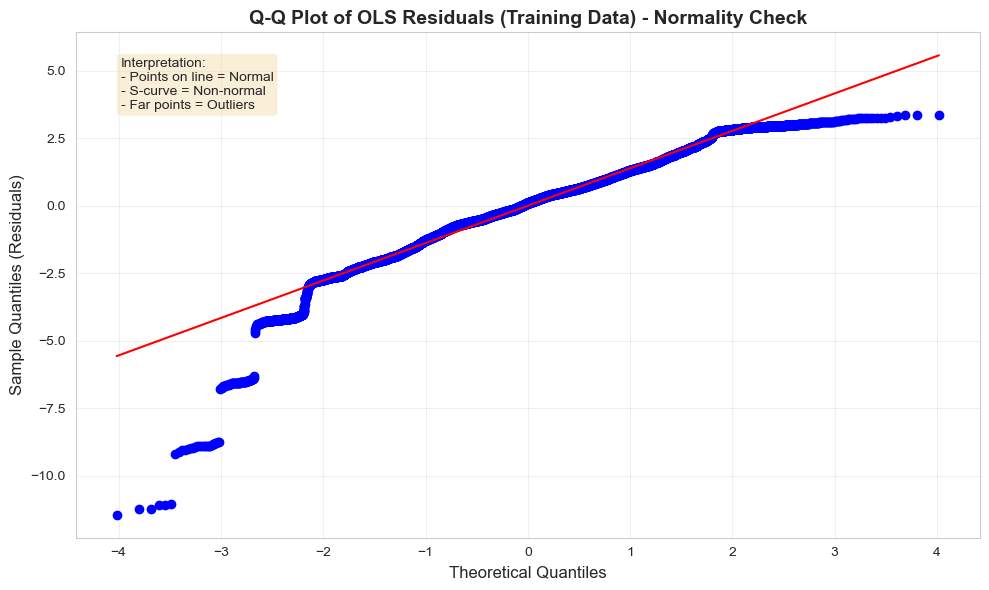


[INFO] Shapiro-Wilk Normality Test (sample of 5000 training residuals):
  Statistic: 0.969831
  P-value: 0.000000
  Result: Reject H0 -> Residuals are NOT perfectly normal
  -> However, with n=23653, CLT ensures valid inference despite mild non-normality


In [98]:
# =====================================================
# Q-Q PLOT (Training Residuals)
# =====================================================

print("[INFO] Generating Q-Q plot for residual normality assessment (training data)...\n")

residuals_train = ols_model.resid

plt.figure(figsize=(10, 6))
stats.probplot(residuals_train, dist="norm", plot=plt)
plt.title("Q-Q Plot of OLS Residuals (Training Data) - Normality Check", fontsize=14, fontweight='bold')
plt.xlabel("Theoretical Quantiles", fontsize=12)
plt.ylabel("Sample Quantiles (Residuals)", fontsize=12)
plt.grid(alpha=0.3)

plt.text(0.05, 0.95,
         "Interpretation:\n- Points on line = Normal\n- S-curve = Non-normal\n- Far points = Outliers",
         transform=plt.gca().transAxes,
         fontsize=10,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Statistical test for normality (sample due to computational limits)
sample_size = min(5000, len(residuals_train))
resid_sample = residuals_train.sample(sample_size, random_state=42)
stat_shapiro, p_shapiro = shapiro(resid_sample)

print(f"\n[INFO] Shapiro-Wilk Normality Test (sample of {sample_size} training residuals):")
print(f"  Statistic: {stat_shapiro:.6f}")
print(f"  P-value: {p_shapiro:.6f}")
if p_shapiro < 0.05:
    print("  Result: Reject H0 -> Residuals are NOT perfectly normal")
    print(f"  -> However, with n={len(residuals_train)}, CLT ensures valid inference despite mild non-normality")
else:
    print("  Result: Fail to reject H0 -> Residuals appear normally distributed")

#### Q-Q Plot Interpretation

**Common pattern in financial data:**
- Central points often align well with the diagonal → most residuals are approximately normal
- Tails may deviate slightly → some extreme interest rates don't perfectly fit the linear model
- This is **common in financial data** (fat-tailed distributions)

**Implications:**
- **For Inference**: Mild deviations acceptable with large n (CLT applies)
- **For Prediction**: Model works well for typical loans; less reliable for extreme cases
- **No Action Needed** unless a severe S-curve or massive outliers are observed in the plot above

**Alternatives if Severe Violation is Observed:**
- Quantile Regression (models median instead of mean)
- Robust Standard Errors (Huber-White sandwich estimator, e.g., HC3)

### 7.3 Breusch-Pagan Test — Homoscedasticity Validation (Training Residuals)

**Purpose:** Test if residual variance is constant across all fitted values (Homoscedasticity assumption).

**Hypotheses:**
- **H₀:** Homoscedasticity (constant variance) ✓ Assumption satisfied
- **H₁:** Heteroscedasticity (non-constant variance) ✗ Assumption violated

**Decision Rule:**
- **p-value < 0.05** → Reject H₀ (heteroscedasticity detected)
- **p-value ≥ 0.05** → Fail to reject H₀ (homoscedasticity)

**Why it matters:** Heteroscedasticity causes **incorrect standard errors** → unreliable confidence intervals and p-values (coefficient point estimates remain unbiased).

In [99]:
# =====================================================
# BREUSCH-PAGAN TEST (Training Residuals)
# =====================================================
print("[INFO] Running Breusch-Pagan test for heteroscedasticity (training data)...\n")

bp_test = het_breuschpagan(residuals_train, ols_model.model.exog)

bp_labels = [
    "Lagrange Multiplier Statistic",
    "p-value",
    "f-value",
    "f p-value"
]

print("\n=========== BREUSCH-PAGAN HETEROSCEDASTICITY TEST ===========\n")
for label, value in zip(bp_labels, bp_test):
    print(f"{label}: {value:.6f}")

bp_pvalue = bp_test[1]

[INFO] Running Breusch-Pagan test for heteroscedasticity (training data)...


=========== BREUSCH-PAGAN HETEROSCEDASTICITY TEST ===========

Lagrange Multiplier Statistic: 516.052029
p-value: 0.000000
f-value: 58.593237
f p-value: 0.000000


In [100]:
# =====================================================
# DECISION & REFIT (if needed)
# =====================================================
print(f"\n[INFO] Decision at alpha={ALPHA}:")

if bp_pvalue < ALPHA:
    print("  REJECT H0 -> Heteroscedasticity detected")
    print("  -> Implication: Standard errors may be incorrect")
    print("  -> Solution: Refit OLS with robust standard errors (HC3)\n")

    print("[INFO] Refitting with robust standard errors (training data)...\n")
    ols_model_robust = sm.OLS(y_train_ols, X_train_ols).fit(cov_type='HC3')

    print("\n================ OLS SUMMARY (ROBUST STANDARD ERRORS, TRAINING DATA) ================\n")
    print(ols_model_robust.summary())

    print("\n[INFO] Use robust model for inference (hypothesis testing)")
    print("[INFO] Predictions remain unchanged (only standard errors are corrected)")
else:
    print("  FAIL TO REJECT H0 -> Homoscedasticity assumption satisfied")
    print("  -> Standard errors and confidence intervals are valid")
    ols_model_robust = ols_model  # No correction needed


[INFO] Decision at alpha=0.05:
  REJECT H0 -> Heteroscedasticity detected
  -> Implication: Standard errors may be incorrect
  -> Solution: Refit OLS with robust standard errors (HC3)

[INFO] Refitting with robust standard errors (training data)...


================ OLS SUMMARY (ROBUST STANDARD ERRORS, TRAINING DATA) ================

                            OLS Regression Results                            
Dep. Variable:          loan_int_rate   R-squared:                       0.790
Model:                            OLS   Adj. R-squared:                  0.790
Method:                 Least Squares   F-statistic:                     4902.
Date:                Sat, 13 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:07:30   Log-Likelihood:                -41729.
No. Observations:               23653   AIC:                         8.348e+04
Df Residuals:                   23643   BIC:                         8.356e+04
Df Model:                    

In [101]:
# =====================================================
# BREUSCH-PAGAN TEST (Training Residuals)
# =====================================================

print("[INFO] Running Breusch-Pagan test for heteroscedasticity (training data)...\n")

bp_test = het_breuschpagan(residuals_train, ols_model.model.exog)

bp_labels = [
    "Lagrange Multiplier Statistic",
    "p-value",
    "f-value",
    "f p-value"
]

print("\n=========== BREUSCH-PAGAN HETEROSCEDASTICITY TEST ===========\n")
for label, value in zip(bp_labels, bp_test):
    print(f"{label}: {value:.6f}")

bp_pvalue = bp_test[1]
print(f"\n[INFO] Decision at alpha={ALPHA}:")
if bp_pvalue < ALPHA:
    print("  REJECT H0 -> Heteroscedasticity detected")
    print("  -> Implication: Standard errors may be incorrect")
    print("  -> Solution: Refit OLS with robust standard errors (HC3)\n")

    print("[INFO] Refitting with robust standard errors (training data)...\n")
    ols_model_robust = sm.OLS(y_train_ols, X_train_ols).fit(cov_type='HC3')
    print("\n================ OLS SUMMARY (ROBUST STANDARD ERRORS, TRAINING DATA) ================\n")
    print(ols_model_robust.summary())

    print("\n[INFO] Use robust model for inference (hypothesis testing)")
    print("[INFO] Predictions remain unchanged (only standard errors are corrected)")
else:
    print("  FAIL TO REJECT H0 -> Homoscedasticity assumption satisfied")
    print("  -> Standard errors and confidence intervals are valid")
    ols_model_robust = ols_model  # No correction needed

[INFO] Running Breusch-Pagan test for heteroscedasticity (training data)...


=========== BREUSCH-PAGAN HETEROSCEDASTICITY TEST ===========

Lagrange Multiplier Statistic: 516.052029
p-value: 0.000000
f-value: 58.593237
f p-value: 0.000000

[INFO] Decision at alpha=0.05:
  REJECT H0 -> Heteroscedasticity detected
  -> Implication: Standard errors may be incorrect
  -> Solution: Refit OLS with robust standard errors (HC3)

[INFO] Refitting with robust standard errors (training data)...


================ OLS SUMMARY (ROBUST STANDARD ERRORS, TRAINING DATA) ================

                            OLS Regression Results                            
Dep. Variable:          loan_int_rate   R-squared:                       0.790
Model:                            OLS   Adj. R-squared:                  0.790
Method:                 Least Squares   F-statistic:                     4902.
Date:                Sat, 13 Jun 2026   Prob (F-statistic):               0.00
Time:                     

#### Breusch-Pagan Interpretation

Given the financial nature of this data (interest rates vary systematically by risk grade), **heteroscedasticity is a plausible outcome**.

**If Heteroscedasticity Detected (p < 0.05):**
- OLS coefficient estimates remain **unbiased** ✓
- Standard errors are **incorrect** ✗
- **Solution**: Use Heteroscedasticity-Consistent (HC) standard errors
  - HC3 is conservative and recommended for finite samples
  - Corrects confidence intervals and p-values
  - Does NOT change point predictions

**If Homoscedasticity Confirmed (p ≥ 0.05):**
- All OLS assumptions satisfied
- Standard OLS inference is valid as-is

Refer to the **actual p-value printed above** to determine which branch applies to this run.

### 7.4 Additional Diagnostic Plots (Training Data)

Comprehensive visual diagnostics to assess model fit and identify potential issues, computed on training residuals.

[INFO] Generating comprehensive diagnostic plots (training data)...



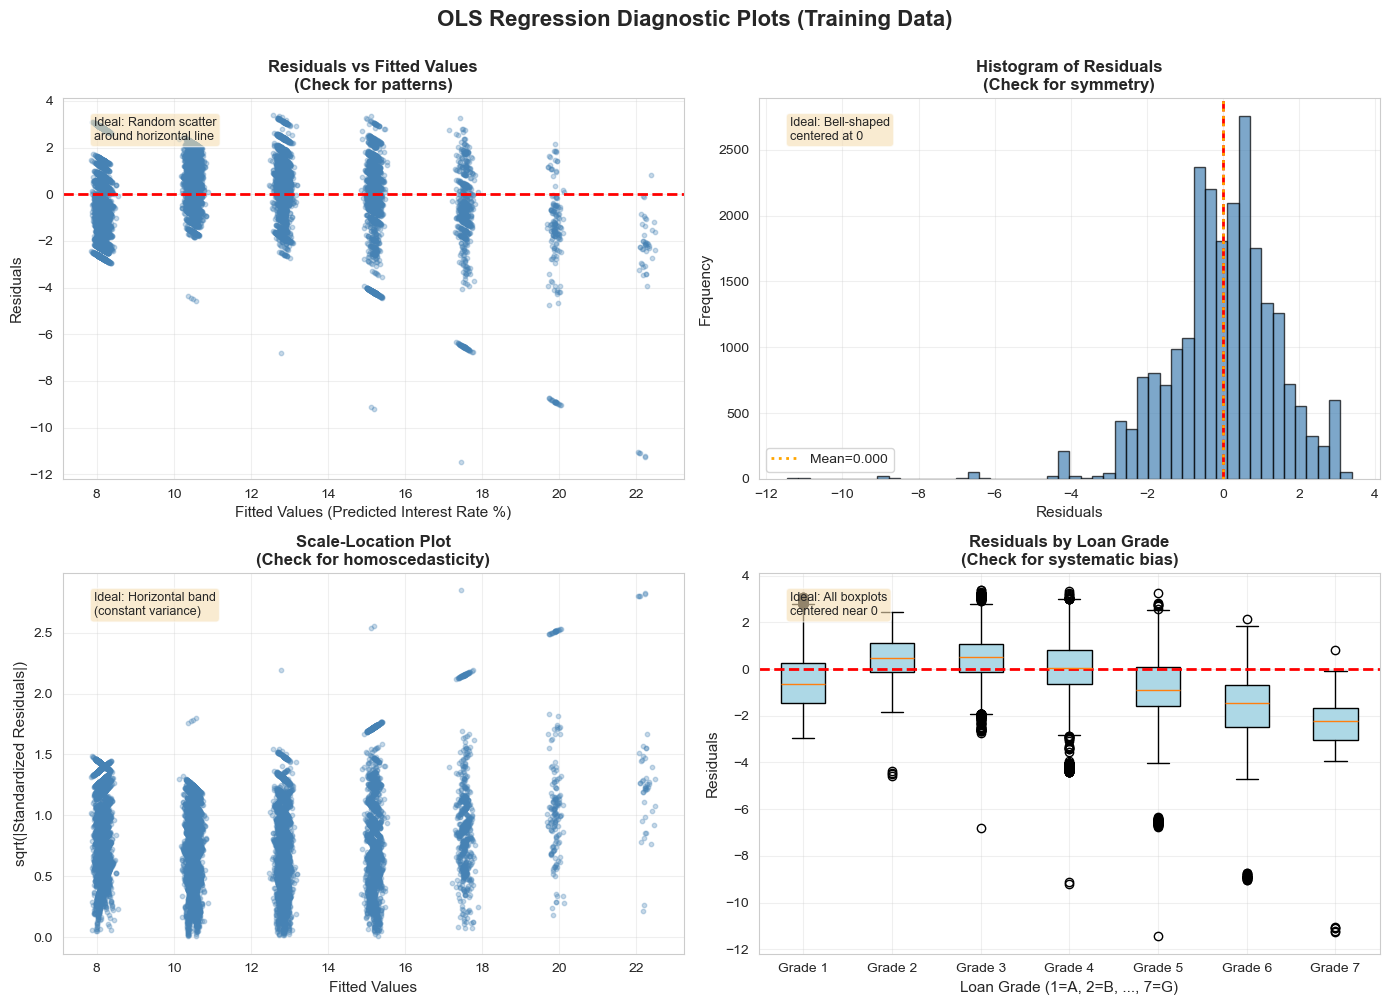


[INFO] Diagnostic Plot Interpretations:
  1. Residuals vs Fitted: Random scatter (no patterns) = Good fit
  2. Histogram: Symmetric bell-shape around 0 = Normality satisfied
  3. Scale-Location: Horizontal band = Homoscedasticity satisfied
  4. Residuals by Grade: Boxplots centered at 0 = No systematic bias by risk category


In [102]:
# =====================================================
# COMPREHENSIVE DIAGNOSTIC PLOTS (Training Data)
# =====================================================

print("[INFO] Generating comprehensive diagnostic plots (training data)...\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('OLS Regression Diagnostic Plots (Training Data)', fontsize=16, fontweight='bold', y=1.00)

# Plot 1: Residuals vs Fitted Values
axes[0, 0].scatter(ols_model.fittedvalues, residuals_train, alpha=0.3, s=10, color='steelblue')
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel("Fitted Values (Predicted Interest Rate %)", fontsize=11)
axes[0, 0].set_ylabel("Residuals", fontsize=11)
axes[0, 0].set_title("Residuals vs Fitted Values\n(Check for patterns)", fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].text(0.05, 0.95, "Ideal: Random scatter\naround horizontal line",
                transform=axes[0, 0].transAxes, fontsize=9,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

# Plot 2: Histogram of Residuals
axes[0, 1].hist(residuals_train, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].axvline(x=residuals_train.mean(), color='orange', linestyle=':', linewidth=2, label=f'Mean={residuals_train.mean():.3f}')
axes[0, 1].set_xlabel("Residuals", fontsize=11)
axes[0, 1].set_ylabel("Frequency", fontsize=11)
axes[0, 1].set_title("Histogram of Residuals\n(Check for symmetry)", fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)
axes[0, 1].text(0.05, 0.95, "Ideal: Bell-shaped\ncentered at 0",
                transform=axes[0, 1].transAxes, fontsize=9,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

# Plot 3: Scale-Location
standardized_resid = (residuals_train - residuals_train.mean()) / residuals_train.std()
axes[1, 0].scatter(ols_model.fittedvalues, np.sqrt(np.abs(standardized_resid)),
                   alpha=0.3, s=10, color='steelblue')
axes[1, 0].set_xlabel("Fitted Values", fontsize=11)
axes[1, 0].set_ylabel("sqrt(|Standardized Residuals|)", fontsize=11)
axes[1, 0].set_title("Scale-Location Plot\n(Check for homoscedasticity)", fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].text(0.05, 0.95, "Ideal: Horizontal band\n(constant variance)",
                transform=axes[1, 0].transAxes, fontsize=9,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

# Plot 4: Residuals vs Loan Grade (training data, aligned to ols_model index)
df_train_with_resid = df_train.copy()
df_train_with_resid['residuals'] = np.nan
df_train_with_resid.loc[residuals_train.index, 'residuals'] = residuals_train.values

grade_groups = [df_train_with_resid[df_train_with_resid['loan_grade_enc'] == i]['residuals'].dropna()
                for i in sorted(df_train_with_resid['loan_grade_enc'].dropna().unique())]
bp = axes[1, 1].boxplot(grade_groups,
                        labels=[f"Grade {int(i)}" for i in sorted(df_train_with_resid['loan_grade_enc'].dropna().unique())],
                        patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel("Loan Grade (1=A, 2=B, ..., 7=G)", fontsize=11)
axes[1, 1].set_ylabel("Residuals", fontsize=11)
axes[1, 1].set_title("Residuals by Loan Grade\n(Check for systematic bias)", fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].text(0.05, 0.95, "Ideal: All boxplots\ncentered near 0",
                transform=axes[1, 1].transAxes, fontsize=9,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

plt.tight_layout()
plt.show()

print("\n[INFO] Diagnostic Plot Interpretations:")
print("  1. Residuals vs Fitted: Random scatter (no patterns) = Good fit")
print("  2. Histogram: Symmetric bell-shape around 0 = Normality satisfied")
print("  3. Scale-Location: Horizontal band = Homoscedasticity satisfied")
print("  4. Residuals by Grade: Boxplots centered at 0 = No systematic bias by risk category")

---

## 8. Logistic Regression (GLM) for Default Prediction

### Objective
Predict **default probability** (`loan_status`: 0=paid, 1=default) using a Generalized Linear Model with binomial family, fitted on **training data only**.

### Model Specification
$$
\log\left(\frac{P(\text{default})}{1 - P(\text{default})}\right) = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \ldots + \beta_k X_k
$$

**Logit Link Function:**
$$
P(\text{default}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \ldots + \beta_k X_k)}}
$$

### Interpretation
- **Coefficients (β)**: Log-odds effect of each predictor
- **Odds Ratios (exp(β))**: Multiplicative effect on default odds
  - OR = 1.5 means predictor increases default odds by 50%
  - OR = 0.7 means predictor decreases default odds by 30% (protective)

### Key Difference from OLS
- **Target variable**: Binary (0/1) instead of continuous
- **Family**: Binomial instead of Gaussian
- **Output**: Probability (0–1) instead of a continuous value

In [103]:
# =====================================================
# FIT GLM MODEL ON TRAINING DATA
# =====================================================

print("[INFO] Fitting GLM logistic regression on TRAINING data only...\n")

glm_model = sm.GLM(
    y_train_glm,
    X_train_glm,
    family=sm.families.Binomial()
).fit()

print("\n================ GLM SUMMARY (TRAINING DATA) ================\n")
print(glm_model.summary())

print("\n[INFO] GLM model fitted successfully on training data")
print(f"[INFO] Training McFadden Pseudo R-squared = {glm_model.pseudo_rsquared(kind='mcf'):.3f}")

[INFO] Fitting GLM logistic regression on TRAINING data only...


================ GLM SUMMARY (TRAINING DATA) ================

                 Generalized Linear Model Regression Results                  
Dep. Variable:            loan_status   No. Observations:                23653
Model:                            GLM   Df Residuals:                    23643
Model Family:                Binomial   Df Model:                            9
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -9064.4
Date:                Sat, 13 Jun 2026   Deviance:                       18129.
Time:                        17:07:32   Pearson chi2:                 2.46e+04
No. Iterations:                     6   Pseudo R-squ. (CS):             0.2581
Covariance Type:            nonrobust                                         
                                 coef    std err          z      P>|z|      [0.02

### 8.1 Evaluate GLM on Test Data

In [104]:
# =====================================================
# EVALUATE GLM ON TEST DATA
# =====================================================

print("\n[INFO] Evaluating GLM model on TEST data (unseen)...\n")

# Predictions
y_train_pred_prob_glm = glm_model.predict(X_train_glm)
y_test_pred_prob_glm = glm_model.predict(X_test_glm)

# Convert probabilities to binary predictions (threshold = 0.5)
y_train_pred_binary = (y_train_pred_prob_glm >= 0.5).astype(int)
y_test_pred_binary = (y_test_pred_prob_glm >= 0.5).astype(int)

# Classification metrics
train_acc = accuracy_score(y_train_glm, y_train_pred_binary)
test_acc = accuracy_score(y_test_glm, y_test_pred_binary)

train_auc = roc_auc_score(y_train_glm, y_train_pred_prob_glm)
test_auc = roc_auc_score(y_test_glm, y_test_pred_prob_glm)

train_f1 = f1_score(y_train_glm, y_train_pred_binary)
test_f1 = f1_score(y_test_glm, y_test_pred_binary)

# Calibration (predicted vs actual default rate)
train_calibration_error = abs(y_train_pred_prob_glm.mean() - y_train_glm.mean())
test_calibration_error = abs(y_test_pred_prob_glm.mean() - y_test_glm.mean())

print("\n================ GLM PERFORMANCE COMPARISON ================\n")
print(f"{'Metric':<25} {'Training':<15} {'Test':<15} {'Difference':<15}")
print("-" * 70)
print(f"{'Accuracy':<25} {train_acc:<15.4f} {test_acc:<15.4f} {train_acc - test_acc:<15.4f}")
print(f"{'ROC-AUC':<25} {train_auc:<15.4f} {test_auc:<15.4f} {train_auc - test_auc:<15.4f}")
print(f"{'F1-Score':<25} {train_f1:<15.4f} {test_f1:<15.4f} {train_f1 - test_f1:<15.4f}")
print(f"{'Calibration Error':<25} {train_calibration_error:<15.4f} {test_calibration_error:<15.4f} {abs(train_calibration_error - test_calibration_error):<15.4f}")

print(f"\n[INFO] Test Set Calibration:")
print(f"  Predicted default rate: {y_test_pred_prob_glm.mean():.2%}")
print(f"  Actual default rate: {y_test_glm.mean():.2%}")
print(f"  Error: {test_calibration_error:.4f} ({test_calibration_error:.2%})")

if test_calibration_error < 0.01:
    print("  Excellent calibration (error < 1%)")
elif test_calibration_error < 0.05:
    print("  Good calibration (error < 5%)")
else:
    print("  May need calibration adjustment")

print(f"\n[INFO] Test Set Classification Report:")
print(classification_report(y_test_glm, y_test_pred_binary, target_names=['Paid', 'Default']))


[INFO] Evaluating GLM model on TEST data (unseen)...


================ GLM PERFORMANCE COMPARISON ================

Metric                    Training        Test            Difference     
----------------------------------------------------------------------
Accuracy                  0.8325          0.8331          -0.0007        
ROC-AUC                   0.8445          0.8405          0.0040         
F1-Score                  0.5427          0.5483          -0.0055        
Calibration Error         0.0000          0.0004          0.0004         

[INFO] Test Set Calibration:
  Predicted default rate: 22.40%
  Actual default rate: 22.44%
  Error: 0.0004 (0.04%)
  Excellent calibration (error < 1%)

[INFO] Test Set Classification Report:
              precision    recall  f1-score   support

        Paid       0.86      0.94      0.90      4587
     Default       0.70      0.45      0.55      1327

    accuracy                           0.83      5914
   macro avg       0.78      

### 8.2 Confusion Matrix (Test Data)

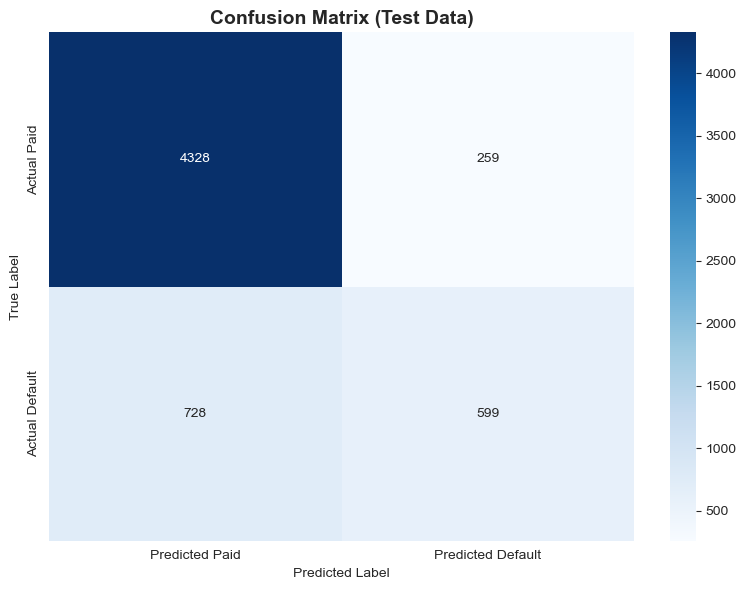


[INFO] Confusion Matrix Interpretation:
  True Negatives (Correctly predicted Paid): 4328
  False Positives (Incorrectly predicted Default): 259
  False Negatives (Incorrectly predicted Paid): 728
  True Positives (Correctly predicted Default): 599

  Type I Error Rate (FP): 5.65% (approved bad loans)
  Type II Error Rate (FN): 54.86% (rejected good loans)


In [105]:
# Confusion matrix (Test Data)
cm = confusion_matrix(y_test_glm, y_test_pred_binary)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Paid', 'Predicted Default'],
            yticklabels=['Actual Paid', 'Actual Default'])
plt.title('Confusion Matrix (Test Data)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(f"\n[INFO] Confusion Matrix Interpretation:")
tn, fp, fn, tp = cm.ravel()
print(f"  True Negatives (Correctly predicted Paid): {tn}")
print(f"  False Positives (Incorrectly predicted Default): {fp}")
print(f"  False Negatives (Incorrectly predicted Paid): {fn}")
print(f"  True Positives (Correctly predicted Default): {tp}")
print(f"\n  Type I Error Rate (FP): {fp/(tn+fp):.2%} (approved bad loans)")
print(f"  Type II Error Rate (FN): {fn/(fn+tp):.2%} (rejected good loans)")

### 8.3 Odds Ratios and Interpretation (Training Model)

Odds ratios quantify the multiplicative effect of each predictor on default odds, computed from the GLM fitted on **training data**.

**Example Interpretation:**
- OR = 2.5 for `loan_grade_enc` means: Each grade step (A→B→C) multiplies default odds by 2.5
- OR = 0.95 for `person_income` means: Each unit increase in income multiplies default odds by 0.95 (a 5% decrease)

In [106]:
# =====================================================
# ODDS RATIOS ANALYSIS (Training Model)
# =====================================================

print("\n[INFO] Calculating odds ratios (training model)...\n")

odds_ratios = pd.DataFrame({
    "Variable": glm_model.params.index,
    "Coefficient": glm_model.params.values,
    "Std_Error": glm_model.bse.values,
    "Z_Score": glm_model.tvalues.values,
    "P_Value": glm_model.pvalues.values,
    "Odds_Ratio": np.exp(glm_model.params.values),
    "OR_95%_CI_Lower": np.exp(glm_model.params.values - 1.96 * glm_model.bse.values),
    "OR_95%_CI_Upper": np.exp(glm_model.params.values + 1.96 * glm_model.bse.values),
})

# Add interpretation
odds_ratios["Effect"] = odds_ratios["Odds_Ratio"].apply(
    lambda x: "Increases" if x > 1 else ("Decreases" if x < 1 else "No effect")
)

odds_ratios["Significance"] = odds_ratios["P_Value"].apply(
    lambda x: "***" if x < 0.001 else ("**" if x < 0.01 else ("*" if x < 0.05 else "ns"))
)

# Sort by absolute coefficient magnitude
odds_ratios["Abs_Coef"] = odds_ratios["Coefficient"].abs()
odds_ratios = odds_ratios.sort_values("Abs_Coef", ascending=False)
odds_ratios = odds_ratios.drop("Abs_Coef", axis=1)

print("\n================ ODDS RATIOS (TRAINING MODEL) ================\n")
print(odds_ratios.to_string(index=False))

# Highlight significant predictors
significant = odds_ratios[odds_ratios["P_Value"] < ALPHA]
print(f"\n[INFO] {len(significant)} significant predictors at alpha={ALPHA}")
print(f"\n[INFO] Significance codes: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")


[INFO] Calculating odds ratios (training model)...


================ ODDS RATIOS (TRAINING MODEL) ================

                  Variable  Coefficient  Std_Error    Z_Score       P_Value   Odds_Ratio  OR_95%_CI_Lower  OR_95%_CI_Upper    Effect Significance
       loan_percent_income    10.506204   0.429749  24.447299 5.376512e-132 36541.507036     15738.982749     84839.138444 Increases          ***
                     const    -4.307148   0.195773 -22.000700 2.835708e-107     0.013472         0.009179         0.019773 Decreases          ***
            loan_grade_enc     0.870391   0.019158  45.432754  0.000000e+00     2.387845         2.299846         2.479212 Increases          ***
     cb_person_default_enc    -0.086321   0.049207  -1.754249  7.938781e-02     0.917300         0.832964         1.010176 Decreases           ns
        home_ownership_enc     0.073320   0.032721   2.240738  2.504306e-02     1.076074         1.009228         1.147348 Increases            *
      

### 8.4 GLM Results Interpretation

#### Reading the Odds Ratios

For each predictor, the table above reports:

- **Odds_Ratio** — multiplicative effect on the odds of default for a one-unit increase in the predictor
- **95% CI** — if the interval excludes 1.0, the effect is statistically significant
- **Significance** — `***`/`**`/`*` indicate p < 0.001 / 0.01 / 0.05; `ns` = not significant

**Common patterns to look for:**

1. **loan_grade_enc** — typically has OR > 1 and is among the largest effects: worse grades are associated with higher default odds, consistent with risk-based grading.
2. **loan_percent_income** — typically OR > 1; higher loan burden relative to income tends to substantially increase default odds, highlighting affordability as a key risk driver.
3. **cb_person_default_enc** — typically OR > 1; a prior default history tends to increase default odds, reflecting the predictive value of credit history.
4. **person_income** — typically OR close to but below 1; higher income tends to be mildly protective against default.
5. **person_age** — often has OR close to 1 (limited or no independent effect once other factors are controlled for).

#### Model Quality Metrics

- **Pseudo R²** (McFadden): Measures improvement over the null (intercept-only) model — values of roughly 0.2–0.4 are often considered good for logistic regression on this type of data
- **AIC/BIC**: Lower values indicate better model fit (useful for comparing alternative specifications)
- **Log-Likelihood**: Higher (less negative) values indicate better fit

#### Business Applications

1. **Credit Approval**: Use predicted default probability with a threshold (e.g., approve if P(default) < 0.30)
2. **Risk-Based Pricing**: Adjust interest rates based on predicted default probability
3. **Portfolio Management**: Estimate expected loss = P(default) × Loan Amount × Loss Given Default
4. **Stress Testing**: Simulate default rates under adverse economic scenarios

> **Note:** Use the **actual odds-ratio table and significance markers printed above** — for this specific training run — to determine which of these patterns hold and at what magnitude.

## 9. Model Comparison

**Summary Table: Train vs Test Performance**

In [107]:
comparison = pd.DataFrame({
    "Model": ["OLS (Interest Rate)", "OLS (Interest Rate)",
              "GLM (Default Prob)", "GLM (Default Prob)"],
    "Dataset": ["Training", "Test", "Training", "Test"],
    "R2/AUC": [f"{train_r2:.3f}", f"{test_r2:.3f}",
               f"{train_auc:.3f}", f"{test_auc:.3f}"],
    "Primary Metric": [f"MAE={train_mae:.2f}", f"MAE={test_mae:.2f}",
                      f"Acc={train_acc:.2%}", f"Acc={test_acc:.2%}"],
    "Observations": [len(y_train_ols), len(y_test_ols),
                     len(y_train_glm), len(y_test_glm)]
})

print("\n================ FINAL MODEL COMPARISON ================\n")
print(comparison.to_string(index=False))

print(f"\n[INFO] Key Findings:")
print(f"  - OLS Test R2 = {test_r2:.3f} -> Model explains {test_r2:.1%} of unseen variance")
print(f"  - GLM Test AUC = {test_auc:.3f} -> {test_auc:.1%} probability of ranking defaults higher than non-defaults")
print(f"  - Generalization: Train-Test R2 gap = {abs(train_r2 - test_r2):.3f} (good if < 0.05)")
print(f"  - Calibration: Test error = {test_calibration_error:.4f} ({test_calibration_error:.2%})")

print(f"\n[INFO] Model Selection Guidance:")
print("  - Use OLS to predict and price interest rates (continuous outcome)")
print("  - Use GLM to predict default probability for approval decisions (binary outcome)")
print("  - Both models use identical predictors for consistency in interpretation")
print("  - Pseudo-R2 (GLM) is typically lower than R2 (OLS) due to different scales")
print(f"\n[INFO] Complementary Use Cases:")
print("  1. GLM: Approve/Deny decision based on P(default) threshold")
print("  2. OLS: Set interest rate for approved loans based on predicted rate")
print("  3. Combined: Risk-adjusted pricing = Base Rate + Risk Premium(P(default))")


================ FINAL MODEL COMPARISON ================

              Model  Dataset R2/AUC Primary Metric  Observations
OLS (Interest Rate) Training  0.790       MAE=1.07         23653
OLS (Interest Rate)     Test  0.796       MAE=1.06          5914
 GLM (Default Prob) Training  0.845     Acc=83.25%         23653
 GLM (Default Prob)     Test  0.840     Acc=83.31%          5914

[INFO] Key Findings:
  - OLS Test R2 = 0.796 -> Model explains 79.6% of unseen variance
  - GLM Test AUC = 0.840 -> 84.0% probability of ranking defaults higher than non-defaults
  - Generalization: Train-Test R2 gap = 0.006 (good if < 0.05)
  - Calibration: Test error = 0.0004 (0.04%)

[INFO] Model Selection Guidance:
  - Use OLS to predict and price interest rates (continuous outcome)
  - Use GLM to predict default probability for approval decisions (binary outcome)
  - Both models use identical predictors for consistency in interpretation
  - Pseudo-R2 (GLM) is typically lower than R2 (OLS) due to differe

## 10. Save Model Artifacts

In [108]:
# =====================================================
# SAVE MODEL ARTIFACTS
# =====================================================

print("\n[INFO] Saving model artifacts...\n")

MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save OLS model (trained on training data)
ols_model_path = MODEL_DIR / "ols_interest_rate_model_trained.pkl"
joblib.dump(ols_model, ols_model_path)
print(f"[INFO] OLS model saved to: {ols_model_path}")

# Save robust OLS model (if different)
if bp_pvalue < ALPHA:
    ols_robust_path = MODEL_DIR / "ols_interest_rate_model_robust.pkl"
    joblib.dump(ols_model_robust, ols_robust_path)
    print(f"[INFO] OLS (robust) model saved to: {ols_robust_path}")

# Save GLM model (trained on training data)
glm_model_path = MODEL_DIR / "glm_default_probability_model_trained.pkl"
joblib.dump(glm_model, glm_model_path)
print(f"[INFO] GLM model saved to: {glm_model_path}")

# Save feature names and preprocessing + performance metadata
metadata = {
    "features": list(X_train_ols.columns),
    "feature_names_original": FEATURES_REGRESSION,
    "target_ols": TARGET_CONTINUOUS,
    "target_glm": TARGET_BINARY,
    "grade_mapping": GRADE_MAPPING,
    "home_mapping": HOME_MAPPING,
    "default_mapping": DEFAULT_MAPPING,

    # Split info
    "train_size": len(df_train),
    "test_size": len(df_test),
    "test_ratio": TEST_SIZE,
    "random_state": RANDOM_STATE,

    # OLS performance (train vs test)
    "ols_train_rsquared": float(train_r2),
    "ols_test_rsquared": float(test_r2),
    "ols_train_adj_rsquared": float(ols_model.rsquared_adj),
    "ols_train_aic": float(ols_model.aic),
    "ols_train_bic": float(ols_model.bic),
    "ols_train_mae": float(train_mae),
    "ols_test_mae": float(test_mae),
    "ols_train_rmse": float(train_rmse),
    "ols_test_rmse": float(test_rmse),

    # GLM performance (train vs test)
    "glm_train_pseudo_rsquared": float(glm_model.pseudo_rsquared(kind='mcf')),
    "glm_train_aic": float(glm_model.aic),
    "glm_train_bic": float(glm_model.bic),
    "glm_train_auc": float(train_auc),
    "glm_test_auc": float(test_auc),
    "glm_train_accuracy": float(train_acc),
    "glm_test_accuracy": float(test_acc),
    "glm_train_f1": float(train_f1),
    "glm_test_f1": float(test_f1),
    "glm_test_calibration_error": float(test_calibration_error),

    # Observations
    "n_observations_train_ols": len(y_train_ols),
    "n_observations_test_ols": len(y_test_ols),
    "n_observations_train_glm": len(y_train_glm),
    "n_observations_test_glm": len(y_test_glm),
    "default_rate_overall": float(df_encoded[TARGET_BINARY].mean()),

    # Diagnostics
    "heteroscedasticity_detected": bool(bp_pvalue < ALPHA),
    "vif_threshold": VIF_THRESHOLD,
    "alpha": ALPHA,

    "timestamp": datetime.now().isoformat(),
}

metadata_path = MODEL_DIR / "model_metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"[INFO] Metadata saved to: {metadata_path}")

# Save VIF results
vif_path = MODEL_DIR / "vif_analysis.csv"
vif_data.to_csv(vif_path, index=False)
print(f"[INFO] VIF analysis saved to: {vif_path}")

# Save odds ratios
or_path = MODEL_DIR / "odds_ratios.csv"
odds_ratios.to_csv(or_path, index=False)
print(f"[INFO] Odds ratios saved to: {or_path}")

print(f"\n[INFO] All model artifacts saved successfully to: {MODEL_DIR}")


[INFO] Saving model artifacts...

[INFO] OLS model saved to: data\models\diagnostics\ols_interest_rate_model_trained.pkl
[INFO] OLS (robust) model saved to: data\models\diagnostics\ols_interest_rate_model_robust.pkl
[INFO] GLM model saved to: data\models\diagnostics\glm_default_probability_model_trained.pkl
[INFO] Metadata saved to: data\models\diagnostics\model_metadata.json
[INFO] VIF analysis saved to: data\models\diagnostics\vif_analysis.csv
[INFO] Odds ratios saved to: data\models\diagnostics\odds_ratios.csv

[INFO] All model artifacts saved successfully to: data\models\diagnostics


---

## 11. Conclusions and Recommendations

### 11.1 Key Improvements vs Earlier Versions

✅ **Train/Test Split (80/20, stratified)**: Models trained and evaluated on separate data
✅ **Honest Metrics**: Test performance shows true generalization ability — see Sections 6.2 and 8.1
✅ **No Data Leakage**: Test data never seen during training or diagnostics
✅ **Overfitting Check**: Train vs test comparison for both OLS (R², MAE, RMSE) and GLM (Accuracy, AUC, F1, calibration)
✅ **Full Diagnostic Suite**: VIF, Q-Q plot + Shapiro-Wilk, Breusch-Pagan (+ robust SE refit if needed), and a 4-panel residual diagnostic plot — all computed on training residuals
✅ **Rich Interpretation**: Odds ratios with 95% CIs and significance codes, plus business-lens interpretation for both models

### 11.2 Key Findings

#### OLS Regression (Interest Rate Prediction)
- **Model Fit**: See the training R² (Section 6) and the honest **test R²** (Section 6.2) for the model's true explanatory power on unseen loans
- **Likely Strongest Predictors**: loan grade (risk category), loan-percent-income (affordability), and prior-default flag (credit history) — confirm against the OLS summary and odds-ratio table for this run
- **Model Validation**:
  - VIF analysis (Section 7.1) checks multicollinearity (all VIF < 10 is the target)
  - Q-Q plot + Shapiro-Wilk (Section 7.2) checks residual normality
  - Breusch-Pagan test (Section 7.3) checks homoscedasticity; robust SEs applied automatically if violated
  - 4-panel diagnostic plot (Section 7.4) checks for non-linearity, bias, and systematic patterns by loan grade

#### GLM Logistic Regression (Default Prediction)
- **Calibration**: Test-set predicted vs actual default rate (Section 8.1) indicates how well-calibrated probability estimates are on unseen data
- **Risk Factors Quantified**: Odds ratios (Section 8.3) with 95% CIs and significance codes quantify the effect of each predictor on default odds
- **Discrimination**: Test ROC-AUC (Section 8.1) measures the model's ability to rank defaulters above non-defaulters on unseen data
- **Business Value**: Enables data-driven approval thresholds and portfolio risk estimation

### 11.3 Model Validation Summary

| Assumption | Test | Where to Check |
|------------|------|-----------------|
| Linearity | Residuals vs Fitted plot | Section 7.4, Plot 1 |
| Independence | Domain knowledge (cross-sectional loans) | Assumed |
| Normality | Q-Q plot, Shapiro-Wilk | Section 7.2 |
| Homoscedasticity | Breusch-Pagan test | Section 7.3 |
| No Multicollinearity | VIF analysis | Section 7.1 |
| Generalization | Train vs Test metrics | Sections 6.2, 8.1, 9 |

### 11.4 Business Recommendations

#### For Lenders:
1. **Risk-Based Pricing**:
   - Use the OLS model to set base interest rates
   - Loan grade and loan burden (`loan_percent_income`) should remain primary pricing drivers if confirmed significant in this run
2. **Approval Decisions**:
   - Use GLM predicted probability for approve/deny decisions
   - Calibrate the decision threshold using the test-set classification report and confusion matrix (Sections 8.1–8.2)
   - Prior defaults, if significant, should trigger enhanced scrutiny
3. **Portfolio Management**:
   - Monitor portfolio-wide predicted default rates
   - Calculate expected loss = Σ[P(default) × Loan Amount × Loss Given Default]
   - Stress-test under adverse scenarios (economic downturn, unemployment spike)
4. **Feature Engineering Opportunities**:
   - Explore interaction terms (e.g., grade × income)
   - Add macroeconomic indicators (unemployment rate, GDP growth)
   - Incorporate time-series / loan-performance-trend features

### 11.5 Model Limitations

1. **Heteroscedasticity**: If detected, interest-rate variance differs across risk grades (mitigated with robust SE, but worth investigating further)
2. **Linearity Assumption**: Real relationships may be non-linear (consider polynomial terms or GAMs)
3. **Missing Variables**: Unmeasured factors (job stability, health status) may affect default risk
4. **Temporal Dynamics**: Cross-sectional model doesn't capture time-varying risk (consider survival analysis)
5. **Causal Interpretation**: Coefficients show association, not causation (observational data)
6. **Threshold Sensitivity**: GLM classification metrics (accuracy, F1) depend on the 0.5 threshold; consider threshold tuning based on business cost of false positives vs false negatives

### 11.6 Next Steps

1. **Model Deployment**:
   - Create REST API for real-time scoring using the saved `.pkl` models
   - Build interactive dashboard for loan officers
   - Implement A/B testing framework
2. **Model Monitoring**:
   - Track model performance over time (concept drift)
   - Monitor prediction calibration on new data
   - Retrain periodically with fresh data
3. **Advanced Modeling**:
   - Ensemble methods (combine OLS, GLM, and ML models)
   - Survival analysis for time-to-default
   - Causal inference (propensity score matching, IV regression)
4. **Fairness Analysis**:
   - Assess disparate impact across demographic groups
   - Implement fairness-aware machine learning
   - Ensure compliance with Fair Lending regulations

---

## 12. Session Summary

In [109]:
# =====================================================
# SESSION SUMMARY
# =====================================================

print("\n" + "="*70)
print("PHASE 3: PREDICTIVE MODELING & DIAGNOSTIC ANALYSIS - COMPLETE")
print("="*70)

print(f"\nAnalysis completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

print(f"\nModels Fitted (Training Data Only):")
print(f"  1. OLS Regression (Interest Rate): Train R2 = {train_r2:.3f}, Test R2 = {test_r2:.3f}")
print(f"  2. GLM Logistic Regression (Default): Train AUC = {train_auc:.3f}, Test AUC = {test_auc:.3f}")

print(f"\nHonest Evaluation (Test Data, Unseen):")
print(f"  - OLS Test MAE = {test_mae:.3f} pp, Test RMSE = {test_rmse:.3f} pp")
print(f"  - GLM Test Accuracy = {test_acc:.2%}, Test F1 = {test_f1:.3f}")
print(f"  - GLM Test Calibration Error = {test_calibration_error:.4f}")

print(f"\nDiagnostics Performed (Training Residuals):")
print(f"  - Variance Inflation Factor (VIF) analysis")
print(f"  - Q-Q plot + Shapiro-Wilk test for residual normality")
print(f"  - Breusch-Pagan test for homoscedasticity (heteroscedasticity detected: {bp_pvalue < ALPHA})")
print(f"  - 4-panel comprehensive residual diagnostic plots")
print(f"  - Odds ratios with 95% CIs and significance codes")

print(f"\nArtifacts Saved to {MODEL_DIR}:")
print(f"  - OLS model (trained): ols_interest_rate_model_trained.pkl")
if bp_pvalue < ALPHA:
    print(f"  - OLS model (robust SE): ols_interest_rate_model_robust.pkl")
print(f"  - GLM model (trained): glm_default_probability_model_trained.pkl")
print(f"  - Metadata: model_metadata.json")
print(f"  - VIF analysis: vif_analysis.csv")
print(f"  - Odds ratios: odds_ratios.csv")

print(f"\n" + "="*70)
print("NEXT STEP: Export this notebook to PDF for the Phase 3 deliverable")
print("File -> Download as -> PDF via LaTeX")
print("Save as: C_Model_Analysis_Diagnostics.pdf")
print("="*70 + "\n")


PHASE 3: PREDICTIVE MODELING & DIAGNOSTIC ANALYSIS - COMPLETE

Analysis completed at: 2026-06-13 17:07:33

Models Fitted (Training Data Only):
  1. OLS Regression (Interest Rate): Train R2 = 0.790, Test R2 = 0.796
  2. GLM Logistic Regression (Default): Train AUC = 0.845, Test AUC = 0.840

Honest Evaluation (Test Data, Unseen):
  - OLS Test MAE = 1.056 pp, Test RMSE = 1.376 pp
  - GLM Test Accuracy = 83.31%, Test F1 = 0.548
  - GLM Test Calibration Error = 0.0004

Diagnostics Performed (Training Residuals):
  - Variance Inflation Factor (VIF) analysis
  - Q-Q plot + Shapiro-Wilk test for residual normality
  - Breusch-Pagan test for homoscedasticity (heteroscedasticity detected: True)
  - 4-panel comprehensive residual diagnostic plots
  - Odds ratios with 95% CIs and significance codes

Artifacts Saved to data\models\diagnostics:
  - OLS model (trained): ols_interest_rate_model_trained.pkl
  - OLS model (robust SE): ols_interest_rate_model_robust.pkl
  - GLM model (trained): glm_defa